# EDA on CHAPA Chapter 40B Application Data 2021-2025
Authors: Belinda (Gia Bao) Ngo, Rohan Banerjee

**Datasets:**
* TOUCHABLE CHAPA Chapter 40B Application Data 2021-2023 & 10|2023-05|2025 (https://docs.google.com/spreadsheets/d/1xcW0qveqOPD-1JvJX1jaSJjPyCVVMGbY/edit?gid=690813037#gid=690813037)
* US Cities (https://github.com/danielmiessler/SecLists/blob/master/Miscellaneous/us-cities.txt)

**Sheets used:** `23-25_data_updated`, `Geocoded Kayla 2021-2023`

**Instruction**: Download the xlsx file above and move it to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

**Output CSV file:** `CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.3.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Load and merge 21-23 and 23-25 datasets

In [2]:
file_path = "../data/TOUCHABLE CHAPA Chapter 40B Application Data 2021-2023 & 10_2023-05_2025.xlsx"

df_2123 = pd.read_excel(file_path, sheet_name="Geocoded Kayla 2021-2023")
df_2325 = pd.read_excel(file_path, sheet_name="23-25_data_updated")

### Check columns

In [3]:
# standardize col names
df_2123.columns = df_2123.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
df_2325.columns = df_2325.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
# df_2123.columns.to_list(), df_2325.columns.to_list()

In [4]:
# check some cols in 23-25 dataset
(df_2325["application_st_address"] == df_2325["street_address"]).all(), (df_2325["application_city_town"] == df_2325["city"]).all()

(np.True_, np.True_)

In [5]:
rename_col_dict_2123 = {"age_unfilled": "age",
                        "chapa_race_ethnicity": "chapa_races",
                        "census_hispanic_latino": "hispanic_latino",
                        "census_race": "census_races",
                        "current_residence_town": "current_residence_town_city",
                        "source": "application_source",
                        "dependents_unfilled": "dependents",
                        "hh_income_unfilled": "hh_income",
                        "hh_assets_unfilled": "hh_assets",
                        "property_unit_number": "property_unit",
                        "property_town": "property_town_city",
                        "state": "property_state",
                        "zip": "property_zip"}
rename_col_dict_2325 = {"application_property": "property_full_address",
                        "application_city_town": "property_town_city",
                        "application_st_address": "property_street_address",
                        "application_unit": "property_unit",
                        "source_new": "application_source",
                        "race_combination_normalized": "chapa_races",
                        "hh_type_standardized": "hh_type",
                        "state": "property_state",
                        "zip": "property_zip"}

# rename cols
df_2123 = df_2123.rename(columns=rename_col_dict_2123)
df_2325 = df_2325.rename(columns=rename_col_dict_2325)

drop_col_list_2123 = ["age_missing_flag",
                        "age_filled",
                        "dependents_missing_flag",
                        "dependents_filled",
                        "hh_income_missing_flag",
                        "hh_income_filled",
                        "hh_assets_missing_flag",
                        "hh_assets_filled"]
drop_col_list_2325 = ["submission_time",
                        "street_address",
                        "city"]

# drop cols
df_2123 = df_2123.drop(columns=drop_col_list_2123, axis=1)
df_2325 = df_2325.drop(columns=drop_col_list_2325, axis=1)

### Merge and rearrange columns

In [6]:
df = pd.concat([df_2123, df_2325], ignore_index=True).assign(current_residence_zip=np.nan)

In [7]:
# rerrange cols
col_order = ["id_number",
            "submission_date",
            "age",
            "disability",
            "chapa_races",
            "hispanic_latino",
            "census_races",
            "current_residence_town_city",
            "current_residence_state",
            "current_residence_zip",
            "application_source",
            "hh_size",
            "dependents",
            "hh_type",
            "hh_income",
            "hh_assets",
            "income_bracket",
            "asset_bracket",
            "unique_id",
            "property_full_address",
            "property_street_address",
            "property_unit",
            "property_town_city",
            "property_state",
            "property_zip",
            "match_status",
            "match_type",
            "matched_address",
            "fthb_class",
            "msa"]
df = df[col_order]

In [8]:
df.head()

,id_number,submission_date,age,disability,chapa_races,hispanic_latino,census_races,current_residence_town_city,current_residence_state,current_residence_zip,...,property_street_address,property_unit,property_town_city,property_state,property_zip,match_status,match_type,matched_address,fthb_class,msa
0,150733,2022-02-08,65,0,White/Non-Minority,0.0,White alone,Somerville,MA,NaN,...,8 Ciderpress Way,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",NaN,"Boston-Cambridge-Newton, MA-NH"
1,439181,2022-02-08,59,0,Hispanic/Latino,1.0,Unknown,Westford,MA,NaN,...,8 Ciderpress Way,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",NaN,"Boston-Cambridge-Newton, MA-NH"
2,697399,2022-02-08,NaN,0,Black or African American,0.0,Black or African American alone,Malden,MA,NaN,...,8 Ciderpress Way,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",NaN,"Boston-Cambridge-Newton, MA-NH"
3,191565,2022-02-08,NaN,0,White/Non-Minority,0.0,White alone,Haverhill,MA,NaN,...,8 Ciderpress Way,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",NaN,"Boston-Cambridge-Newton, MA-NH"
4,226436,2022-02-08,60,0,White/Non-Minority,0.0,White alone,Nashua,NH,NaN,...,8 Ciderpress Way,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",NaN,"Boston-Cambridge-Newton, MA-NH"


## Explore and clean merged dataset

In [18]:
# check dtypes and nulls
# df.info(), df.isnull().sum().sort_values(ascending=False)

In [19]:
print(f"total applications: {len(df["id_number"])}, total applicants: {df["id_number"].nunique()}")
print(f"total CHAPA properties in this dataset: {df["property_street_address"].nunique()}")

total applications: 1739, total applicants: 1298
total CHAPA properties in this dataset: 91


In [20]:
# age: replace "u/a" with NaN and "66.5" with "66" and "4" with "0", all missing is "0", and convert to int dtype
df["age"] = df["age"].replace({"u/a": np.nan, 66.5: 66, 4: 0}).fillna(0).astype(int)

# disability: 1 for "Yes"; 0 for "No", "Choose not to answer", "Missing"
df["disability"] = df["disability"].replace({"Yes": 1, "No": 0, "no": 0, "Choose not to answer": 0, np.nan: 0}).astype(int)

# current_residence_state: standardize to "MA", change nan to "Unknown"
for x in ["Ma", "ma", "Massachusetts"]:
    df["current_residence_state"] = df["current_residence_state"].replace({x: "MA"})
df["current_residence_state"] = df["current_residence_state"].replace({np.nan: "Unknown"})

# application_source: nan to "Unknown"
df["application_source"] = df["application_source"].replace({np.nan: "Unknown"})

# hh_type: strip leading and trailing whitespaces
df["hh_type"] = df["hh_type"].str.strip().replace({np.nan: "Unknown"})

# fthb_class: 1 for "Yes"; 0 for "No" and nan
df["fthb_class"] = df["fthb_class"].replace({"Yes": 1, "No": 0, np.nan: 0}).astype(int)

# msa: standardize to "Boston-Cambridge-Newton, MA-NH"
df["msa"] = df["msa"].replace({"Boston-Cambridge-Newton, MA-NH": "Boston-Cambridge-Newton, MA-NH",
                                    "Boston-Cambridge-Newton, MA–NH ": "Boston-Cambridge-Newton, MA-NH",
                                    "Boston-Cambridge-Newton, MA–NH": "Boston-Cambridge-Newton, MA-NH"})

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/61439469.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["age"] = df["age"].replace({"u/a": np.nan, 66.5: 66, 4: 0}).fillna(0).astype(int)
/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/61439469.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["disability"] = df["disability"].replace({"Yes": 1, "No": 0, "no": 0, "Choose not to answer": 0, np.nan: 0}).astype(int)
/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/61439469.p

In [21]:
# property_unit

# extract unit from property_full_address from 23-25 dataset
def extract_unit(addy):
    if pd.isna(addy):
        return None
    addy = addy.lower()
    match = re.search(r"unit\s*([^~]*)", addy)
    if match:
        return match.group(1).strip()
    return None

# only fill for null property_unit rows
df.loc[df["property_unit"].isna(), "property_unit"] = df.loc[df["property_unit"].isna(), "property_full_address"].apply(extract_unit)

# standardize values: remove "Unit", "#", and extra spaces
df["property_unit"] = (
    df["property_unit"]
    .str.replace(r"(?i)unit", "", regex=True)   # case insensitive
    .str.replace("#", "", regex=False)
    .str.strip()
)

In [22]:
# property_street_address: remove "Unit xxx" at the end of the string if exists
df["property_street_address"] = df["property_street_address"].str.replace(r"\s+Unit\s+\S+$", "", regex=True, case=False).str.strip()

In [23]:
# current_residence_town_city, property_town_city

# import US cities reference list
file_path = "../data/us-cities.txt"
with open(file_path) as f:
    cities = set(line.strip() for line in f if line.strip())

# find / spell check which city values are NOT in the reference list
col = "current_residence_town_city"
# col = "property_town_city"
df_cities = set(df[col].dropna().unique())
# sorted(df_cities - cities) # cities not found in reference list

# current_residence_town_city
clean_city_dict = {"LOWELL": "Lowell",
                    "Lowell Massachusetts": "Lowell",
                    "Lynn Ma": "Lynn",
                    "Nasuha Nh": "Nashua",
                    "Arlignton": "Arlington",
                    "Marlborugh": "Marlborough",
                    "hudson": "Hudson",
                    "Tewskbury": "Tewksbury",
                    "Rosindale": "Roslindale",
                    "Miflord": "Milford",
                    "Yarmouthport": "Yarmouth Port",
                    "S. Hamilton": "South Hamilton",
                    "Burlignton": "Burlington",
                    "Newberyport": "Newburyport",
                    "North Attleboro": "North Attleborough",
                    "Walthan": "Waltham",
                    "New Bedford / Worcester": "Worcester",     # same id_number has "Worcester" for other applications
                    "New Bedford/ Worcester": "Worcester"}
df["current_residence_town_city"] = df["current_residence_town_city"].replace(clean_city_dict).replace({np.nan: "Unknown"})

# property_town_city
df["property_town_city"] = df["property_town_city"].replace({"Warehem": "Wareham"})

In [24]:
# property_restriction
# some property_full_address rows have age-restriction or first come, first serve info -> new col property_restriction

def extract_all_parentheses(text):
    if pd.isna(text):
        return None

    matches = re.findall(r"\(([^()]*)\)", text)
    if not matches:
        return None

    parts = []
    for m in matches:
        m = m.lower().strip()

        # normalize variations before splitting
        m = re.sub(r"first\s*come[,;]?\s*first\s*serve[d]?", "first come first served", m)

        # split by semicolon/comma if multiple restrictions exist
        for p in re.split(r"[;,]", m):
            clean = p.strip()
            if clean:
                parts.append(clean)

    parts = sorted(set(parts))
    return "; ".join(parts)

df["property_restriction"] = df["property_full_address"].apply(extract_all_parentheses)

### Next steps

* **!ROHAN!** clean races: cols `chapa_races`, `hispanic_latino`, `census_races`
    * fill in dummy col `hispanic_latino` from parsing through `hispanic_latino`
    * one hot encode `chapa_races`

* **!JOY!** geocode `current_residence_zip`
    * pick zipcode with most pop

* `hh_size`: 20, 31

* `hh_income`, `hh_assets`, `income_bracket`, `asset_bracket`

* `property_restriction`, `first_come_first_served`
    * talk to Ria and Aastha to pull this from resale data

* geocode `matched_address`
    * some non-exact matched addresses are incorrect
    * Zillow match probably ok
    * handle misspelled matches
    * geocode nulls

* create `unique_id` for 21-23 rows

## Clean race columns

In [25]:
def parse_race_string(race_str):
    if pd.isna(race_str):
        return []

    s = race_str.lower().strip()

    # "white/non-minority" to just white
    s = re.sub(r"\bwhite\s*/\s*non[- ]?minority\b", "white", s)

    # Keep Hispanic/Latino as a single ethnicity
    s = re.sub(r"\bhispanic\s*/\s*latino\b", "hispanic or latino", s)

    # Expand Asian/Pacific Islander to full phrasing
    s = re.sub(r"\basian\s*/\s*pacific islander\b",
               "asian, native hawaiian or pacific islander", s)

    # Normalize Native American/Alaskan 
    s = re.sub(r"\bnative american\s*/\s*alaskan native\b",
               "native american or alaskan native", s)

    # Normalize MENA variants
    s = re.sub(r"\bnorth african or middle eastern\b", 
               "middle eastern or north african", s)

    # Normalize “Black or African American”
    s = re.sub(r"\bblack\s*or\s*african american\b", 
               "black or african american", s)

    # split ONLY on commas/semicolons (NOT on /)
    parts = [p.strip() for p in re.split(r"[;,]", s) if p.strip()]

    return sorted(set(parts))

In [26]:
df['race_list'] = df['chapa_races'].apply(parse_race_string)
df['race_count'] = df['race_list'].apply(len)

def canonical_race(race_terms):
    if not race_terms:
        return ["Other / Prefer not to answer"]

    canonical = []
    for term in race_terms:
        t = term.lower().strip()

        # 1) HIGH-PRIORITY special cases first
        if ("middle eastern" in t) or ("north african" in t):
            canonical.append("Middle Eastern or North African")
            continue  # prevent falling into "african" → Black

        if ("minority" in t and "non" in t) or t == "non-minority" or t == "white/non-minority":
            canonical.append("White")
            continue

        # 2) Standard race buckets
        if "white" in t:
            canonical.append("White")
        elif "asian" in t:
            canonical.append("Asian")
        elif ("pacific" in t) or ("hawaiian" in t):
            canonical.append("Native Hawaiian or Pacific Islander")
        elif "hispanic" in t or "latino" in t:
            canonical.append("Hispanic or Latino")
        elif "native" in t and ("american" in t or "alaskan" in t):
            canonical.append("American Indian or Alaska Native")
        elif "black" in t or "african" in t:
            # Now safe: won't swallow "north african" because MENA already handled
            canonical.append("Black or African American")
        elif any(x in t for x in ["other", "choose", "missing", "unknown", "prefer not to answer"]):
            canonical.append("Other / Prefer not to answer")

    canonical = sorted(set(canonical))
    return canonical if canonical else ["Other / Prefer not to answer"]

df['race_list']   = df['chapa_races'].apply(parse_race_string)
df['race_cleaned'] = df['race_list'].apply(canonical_race)
df['race_type']    = np.where(df['race_cleaned'].apply(len) > 1, "Multiracial", "Single Race")

In [27]:
unique_races = sorted({r for lst in df['race_cleaned'] for r in lst})
for race in unique_races:
    col = f"race_{race.replace(' ', '_').replace('/', '')}"
    df[col] = df['race_cleaned'].apply(lambda L: int(race in L))
    
unique_races

['American Indian or Alaska Native',
 'Asian',
 'Black or African American',
 'Hispanic or Latino',
 'Middle Eastern or North African',
 'Native Hawaiian or Pacific Islander',
 'Other / Prefer not to answer',
 'White']

In [28]:
df['hispanic_latino_from_race'] = df['race_cleaned'].apply(lambda r: int("Hispanic or Latino" in r))
if 'hispanic_latino' in df.columns:
    df['hispanic_latino_final'] = (
        pd.to_numeric(df['hispanic_latino'], errors='coerce')
          .fillna(df['hispanic_latino_from_race'])
          .astype(int)
    )
else:
    df['hispanic_latino_final'] = df['hispanic_latino_from_race']

In [29]:
df[['chapa_races', 'race_cleaned', 'race_type'] + 
   [col for col in df.columns if col.startswith('race_')]].head(10)

,chapa_races,race_cleaned,race_type,race_list,race_count,race_cleaned,race_type,race_American_Indian_or_Alaska_Native,race_Asian,race_Black_or_African_American,race_Hispanic_or_Latino,race_Middle_Eastern_or_North_African,race_Native_Hawaiian_or_Pacific_Islander,race_Other__Prefer_not_to_answer,race_White
0,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
1,Hispanic/Latino,[Hispanic or Latino],Single Race,[hispanic or latino],1,[Hispanic or Latino],Single Race,0,0,0,1,0,0,0,0
2,Black or African American,[Black or African American],Single Race,[black or african american],1,[Black or African American],Single Race,0,0,1,0,0,0,0,0
3,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
4,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
5,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
6,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
7,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
8,Black or African American,[Black or African American],Single Race,[black or african american],1,[Black or African American],Single Race,0,0,1,0,0,0,0,0
9,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial,"[asian, native hawaiian or pacific islander]",2,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial,0,1,0,0,0,1,0,0


### Race Data Cleaning & Encoding Summary

- **Objective:** Standardize and encode applicant race information from the `chapa_races` column, aligning with U.S. Census categories and ensuring consistency for equity and demographic analysis.
- **Steps:**
  1. Parsed raw text using an improved `parse_race_string()` that preserved multi-race combinations and normalized ambiguous labels.
  2. Canonically mapped all responses to **eight** standardized categories:  
     *White, Black or African American, Asian, Hispanic or Latino, American Indian or Alaska Native, Native Hawaiian or Pacific Islander, Middle Eastern or North African, Other / Prefer not to answer.*
  3. Created `race_type` to distinguish **Single Race** vs **Multiracial** applicants.
  4. Generated one-hot encoded indicator columns (e.g., `race_White`, `race_Asian`) for modeling or aggregation.
  5. Derived a cleaned `hispanic_latino_final` flag aligned with federal ethnicity definitions.
- **Outcome:** A fully standardized race/ethnicity dataset that supports demographic, equity, and income-based analyses across the 2021–25 applicant pool.



### Visualizations

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/4277353770.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")


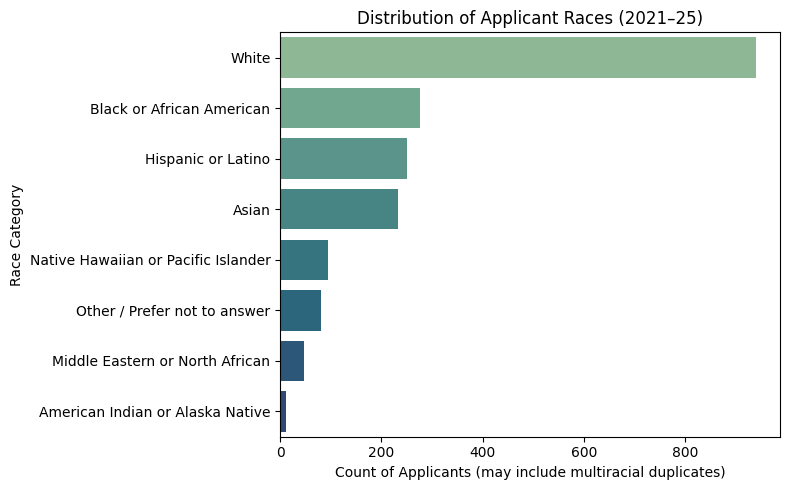

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the list
race_flat = [r for sublist in df['race_cleaned'] for r in sublist]
race_series = pd.Series(race_flat)

plt.figure(figsize=(8,5))
sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")
plt.title("Distribution of Applicant Races (2021–25)")
plt.xlabel("Count of Applicants (may include multiracial duplicates)")
plt.ylabel("Race Category")
plt.tight_layout()
plt.show()

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/1209738690.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='race_type', data=df, palette='pastel')


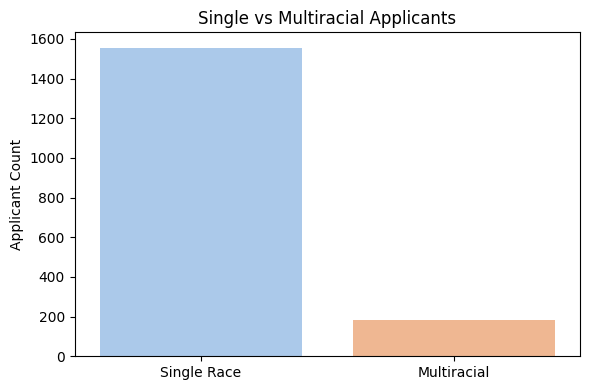

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='race_type', data=df, palette='pastel')
plt.title("Single vs Multiracial Applicants")
plt.xlabel("")
plt.ylabel("Applicant Count")
plt.tight_layout()
plt.show()

In [32]:
df_exploded = df.explode('race_cleaned').reset_index(drop=True)

# Clean and convert household income to numeric
df_exploded['hh_income'] = (
    df_exploded['hh_income']
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

# Clip extreme household incomes for visualization
upper_cap = 500_000
df_exploded['hh_income_clipped'] = df_exploded['hh_income'].clip(upper=upper_cap)

df_exploded[['race_cleaned', 'hh_income_clipped']].head()

,race_cleaned,hh_income_clipped
0,White,37934.0
1,Hispanic or Latino,61000.0
2,Black or African American,31275.0
3,White,20299.0
4,White,41000.0


/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/1452837737.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


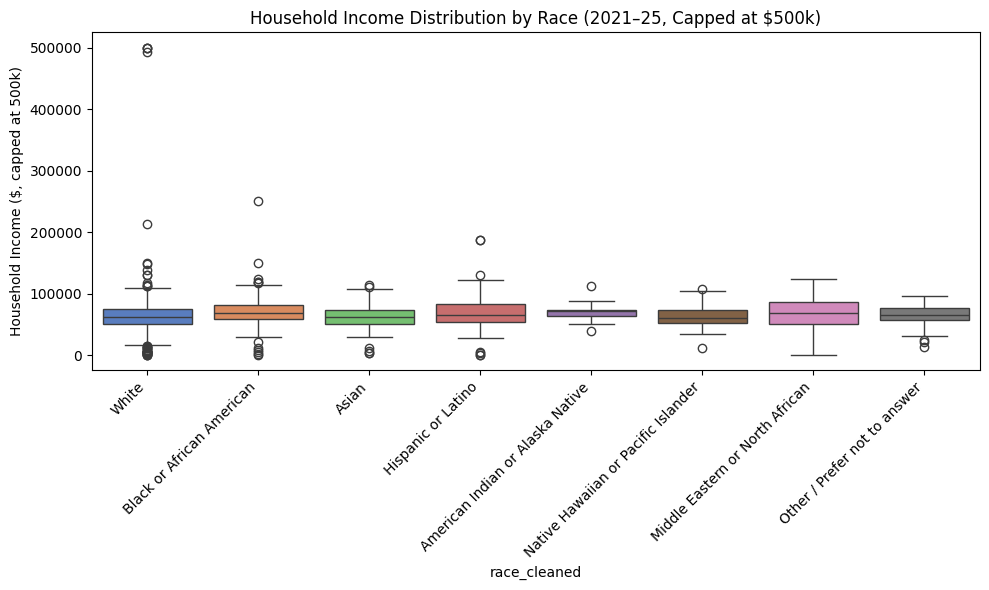

In [33]:
race_order = [
    'White', 'Black or African American', 'Asian', 
    'Hispanic or Latino', 'American Indian or Alaska Native',
    'Native Hawaiian or Pacific Islander', 'Middle Eastern or North African',
    'Other / Prefer not to answer'
]

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_exploded,
    x='race_cleaned', y='hh_income_clipped',
    order= race_order,
    palette='muted'
)
plt.title('Household Income Distribution by Race (2021–25, Capped at $500k)')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Household Income ($, capped at 500k)")
plt.tight_layout()
plt.show()

In [34]:
df_exploded.groupby('race_cleaned')['hh_income_clipped']\
    .describe(percentiles=[.25,.5,.75])

,count,mean,std,min,25%,50%,75%,max
race_cleaned,,,,,,,,
American Indian or Alaska Native,11.0,70384.909091,19337.660466,38400.0,63096.00,72000.0,73500.0,113000.0
Asian,232.0,63154.943966,19488.751809,3000.0,50941.25,62000.0,74000.0,114350.0
Black or African American,277.0,70229.833935,22261.003981,70.0,57867.00,68411.0,81250.0,250000.0
Hispanic or Latino,250.0,68173.168000,23537.766335,100.0,54258.25,65000.0,83000.0,187000.0
Middle Eastern or North African,47.0,67889.659574,24634.081572,96.0,50631.00,68000.0,86200.0,124000.0
Native Hawaiian or Pacific Islander,94.0,62515.457447,16602.368776,11000.0,52240.00,61000.0,73675.0,107000.0
Other / Prefer not to answer,79.0,65860.746835,17560.302092,13149.0,57138.00,65871.0,76418.0,96610.0
White,938.0,63813.351812,35143.691669,78.0,51000.00,62000.0,74640.0,500000.0


In [35]:
q = df_exploded.groupby('race_cleaned')['hh_income_clipped']
summary = pd.DataFrame({
    "n": q.size(),
    "median": q.median(),
    "p25": q.quantile(0.25),
    "p75": q.quantile(0.75)
}).loc[race_order]
summary

,n,median,p25,p75
race_cleaned,,,,
White,941,62000.0,51000.00,74640.0
Black or African American,277,68411.0,57867.00,81250.0
Asian,233,62000.0,50941.25,74000.0
Hispanic or Latino,251,65000.0,54258.25,83000.0
American Indian or Alaska Native,11,72000.0,63096.00,73500.0
Native Hawaiian or Pacific Islander,95,61000.0,52240.00,73675.0
Middle Eastern or North African,47,68000.0,50631.00,86200.0
Other / Prefer not to answer,81,65871.0,57138.00,76418.0


### Race Distribution & Income Insights

- **Representation:**  
  White applicants comprise the majority of the dataset, followed by Black or African American, Hispanic or Latino, and Asian applicants.  
  Smaller groups include Native Hawaiian or Pacific Islander, Middle Eastern or North African, American Indian or Alaska Native, and “Other / Prefer not to answer.”

- **Multiracial Breakdown:**  
  Roughly 85–90% of applicants identify with a single race, while about 10–15% report multiple racial backgrounds—consistent with CHAPA’s broader applicant pool.

- **Income Disparities:**  
  When capped at \$500K to reduce outlier distortion, the **median household income** clusters tightly between \$60K–\$70K across most groups.  
  - White and Asian applicants show slightly higher upper quartiles (~\$74K–\$75K).  
  - Hispanic, Black, and Middle Eastern/North African applicants center around \$65K–\$68K, showing minor variation.  
  - Smaller populations (AI/AN and NH/PI) display higher volatility but similar medians.  
  Overall, no extreme race-linked income disparities appear within the capped dataset.

- **Next Steps:**  
  Future visualizations can examine intersections between **race, geography (tract or city)**, and **outcome variables** (e.g., loan approval, homeownership, outreach success) to explore equity dimensions more deeply.


## Clean the remaining columns

In [37]:
# file_path = "../data/CHAPA_ApplicationData_2021-2025_withRaceCleaned.csv"
# df = pd.read_csv(file_path)
# df.head()

In [38]:
# hh_income: replace "\xa020,000\xa0" with 20000, convert to float, fill na with median (64000.0)
col = "hh_income"
df[col] = df[col].replace({"\xa020,000\xa0": 20000})
df[col] = df[col].astype(float).fillna(df[col].median())

# hh_assets: replace "10,000\xa0" with 10000, convert to float, fill na with median (31424.05)
col = "hh_assets"
df[col] = df[col].replace({"10,000\xa0": 10000})
df[col] = df[col].astype(float).fillna(df[col].median())

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/3547260555.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({"\xa020,000\xa0": 20000})
/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_32726/3547260555.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({"10,000\xa0": 10000})


In [39]:
# income_bracket

col = "income_bracket"

# define bin edges (upper bound inclusive for all but last) and labels
bins = [0, 19999, 39999, 59999, 79999, 99999, 119999, np.inf]
labels = [
    "$0–$19,999",
    "$20,000–$39,999",
    "$40,000–$59,999",
    "$60,000–$79,999",
    "$80,000–$99,999",
    "$100,000–$119,999",
    "$120,000+"
]

df[col] = pd.cut(df['hh_income'], bins=bins, labels=labels, right=True, include_lowest=True)
df[col].value_counts(dropna=False)

income_bracket
$60,000–$79,999      699
$40,000–$59,999      542
$80,000–$99,999      280
$20,000–$39,999      109
$100,000–$119,999     46
$0–$19,999            42
$120,000+             21
Name: count, dtype: int64

In [40]:
# asset_bracket

col = "asset_bracket"

# define bin edges (upper bound inclusive for all but last) and labels
bins = [0, 19999, 39999, 59999, 79999, 99999, 119999, 199999, np.inf]
labels = [
    "$0–$19,999",
    "$20,000–$39,999",
    "$40,000–$59,999",
    "$60,000–$79,999",
    "$80,000–$99,999",
    "$100,000–$119,999",
    "$120,000–$199,999",
    "$200,000+"
]

df[col] = pd.cut(df['hh_assets'], bins=bins, labels=labels, right=True, include_lowest=True)
df[col].value_counts(dropna=False)

asset_bracket
$0–$19,999           580
$20,000–$39,999      451
$40,000–$59,999      298
$60,000–$79,999      281
$200,000+             60
$120,000–$199,999     33
$80,000–$99,999       21
$100,000–$119,999     15
Name: count, dtype: int64

In [41]:
# dependents: fill nulls with -1
col = "dependents"
df[col] = df[col].replace({np.nan: -1}).astype(int)

In [42]:
# rename unique_id
df.rename(columns={'unique_id': 'application_id'}, inplace=True)

In [43]:
# match_type
col = "match_type"
df[col] = df[col].replace({"mispelled": "Mispelled", np.nan: "Needs matching"})

In [44]:
# drop hispanic_latino, property_restriction, race_list, hispanic_latino_from_race, hispanic_latino_final
df.drop(columns=["hispanic_latino",
                    "property_restriction",
                    "race_list",
                    "hispanic_latino_from_race",
                    "hispanic_latino_final"], inplace=True)

In [ ]:
df.to_csv("../data/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.3.csv", index=False)

## Notes for Next team

* lots of towns/neighborhoods in MA needed manual validation -> consider finding and using a txt file of MA towns and cities as a reference list